# 📊 Notebook 01 — Exploratory Data Analysis & Cleaning
## ParkSense AI | Gridlock Round 2 | BTP Parking Violations Dataset

**Dataset:** `data/raw/given.csv`  
**Records:** ~298,450  
**Columns:** 24  
**Time Range:** November 2023 – May 2024  

### Goals of this Notebook
1. Understand raw data shape, types, and quality
2. Identify and handle missing values
3. Parse complex fields (JSON arrays in `violation_type`, `offence_code`)
4. Detect and handle duplicates
5. Understand `validation_status` distribution and decide filtering strategy
6. Explore geographic coverage (lat/lng bounds)
7. Explore temporal coverage and patterns
8. Explore vehicle types and violation type distributions
9. Detect data quality issues specific to this dataset
10. Export a clean DataFrame and a sample CSV for demo uploads

---
> **⚠️ Important:** All analysis uses ONLY the provided dataset. No external data sources used.

## 0. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import ast
import json
import re
import warnings
from collections import Counter

warnings.filterwarnings('ignore')

# Plot style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 11

print('✅ Imports done.')

✅ Imports done.


## 1. Load Raw Data

In [2]:
RAW_PATH = '../data/raw/given.csv'

# low_memory=False because violation_type and offence_code are mixed-type JSON strings
df_raw = pd.read_csv(RAW_PATH, low_memory=False)

print(f'Shape: {df_raw.shape}')
print(f'Rows : {df_raw.shape[0]:,}')
print(f'Cols : {df_raw.shape[1]}')

Shape: (298450, 24)
Rows : 298,450
Cols : 24


In [3]:
# View first 5 rows
df_raw.head()

,id,latitude,longitude,location,vehicle_number,vehicle_type,description,violation_type,offence_code,created_datetime,...,center_code,police_station,data_sent_to_scita,junction_name,action_taken_timestamp,data_sent_to_scita_timestamp,updated_vehicle_number,updated_vehicle_type,validation_status,validation_timestamp
0,FKID000000,12.925557,77.618665,"18th Main Road, Block 2, Koramangala, Bengalur...",FKN00GL0000,CAR,NaN,"[""WRONG PARKING"",""PARKING NEAR ROAD CROSSING""]","[112,104]",2023-11-20 00:28:46+00,...,9.0,Madiwala,True,No Junction,NaN,NaN,FKN00GL0000,MAXI-CAB,approved,2023-11-30 03:08:24.818+00
1,FKID000001,12.905463,77.700778,"Sarjapura Main Road, The Grove, Janatha Colony...",FKN00GL0001,CAR,NaN,"[""NO PARKING""]",[113],2023-11-24 22:46:46+00,...,82.0,Bellandur,False,No Junction,NaN,NaN,NaN,NaN,NaN,NaN
2,FKID000002,12.925449,77.618504,"Koramangala 2nd Block, Kormangala West, Bengal...",FKN00GL0002,CAR,NaN,"[""WRONG PARKING"",""PARKING IN A MAIN ROAD""]","[112,107]",2023-11-20 00:27:46+00,...,9.0,Madiwala,True,No Junction,NaN,NaN,FKN00GL0002,MAXI-CAB,approved,2023-11-30 03:08:56.998+00
3,FKID000003,12.956521,77.518618,"6th Cross Road, Manasa Layout, Nagarbhavi, Ben...",FKN00GL0003,SCOOTER,NaN,"[""NO PARKING""]",[113],2023-11-16 06:47:46+00,...,26.0,Byatarayanapura,True,No Junction,NaN,NaN,FKN00GL0003,SCOOTER,approved,2023-11-18 23:35:12.428+00
4,FKID000004,12.977767,77.580545,"Kalidasa Road, Gandhinagar, Nehru Nagar, Benga...",FKN00GL0004,TANKER,NaN,"[""NO PARKING""]",[113],2023-11-22 04:56:46+00,...,3.0,Upparpet,True,BTP044 - Sagar Theatre Junction,NaN,NaN,FKN00GL0004,TANKER,approved,2023-11-30 03:11:32.796+00


In [4]:
# All column names and their dtypes
df_raw.dtypes

id                               object
latitude                        float64
longitude                       float64
location                         object
vehicle_number                   object
vehicle_type                     object
description                     float64
violation_type                   object
offence_code                     object
created_datetime                 object
closed_datetime                 float64
modified_datetime                object
device_id                        object
created_by_id                    object
center_code                     float64
police_station                   object
data_sent_to_scita                 bool
junction_name                    object
action_taken_timestamp          float64
data_sent_to_scita_timestamp     object
updated_vehicle_number           object
updated_vehicle_type             object
validation_status                object
validation_timestamp             object
dtype: object

## 2. Missing Value Analysis

From visual inspection of the raw CSV we already know several columns are heavily NULL:
- `description` — appears to be ALL 'NULL' strings
- `closed_datetime` — most records are open/never closed
- `action_taken_timestamp` — sparse
- `updated_vehicle_number`, `updated_vehicle_type` — only populated when validation corrects the original
- `validation_status`, `validation_timestamp` — NULL for unvalidated records
- `center_code` — some records have NULL (seen in Kodigehalli station rows)
- `location` — at least one row (FKID000122) has empty location string

In [5]:
# Replace literal 'NULL' strings with actual NaN first
df = df_raw.replace('NULL', np.nan)

# Missing value counts and percentages
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_report = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).sort_values('Missing %', ascending=False)

print(missing_report.to_string())

                              Missing Count  Missing %
description                          298450     100.00
closed_datetime                      298450     100.00
action_taken_timestamp               298450     100.00
data_sent_to_scita_timestamp         256289      85.87
updated_vehicle_type                 125254      41.97
validation_timestamp                 125254      41.97
validation_status                    125254      41.97
updated_vehicle_number               125254      41.97
center_code                           11260       3.77
location                               3041       1.02
violation_type                            0       0.00
vehicle_type                              0       0.00
id                                        0       0.00
latitude                                  0       0.00
vehicle_number                            0       0.00
longitude                                 0       0.00
police_station                            5       0.00
created_by

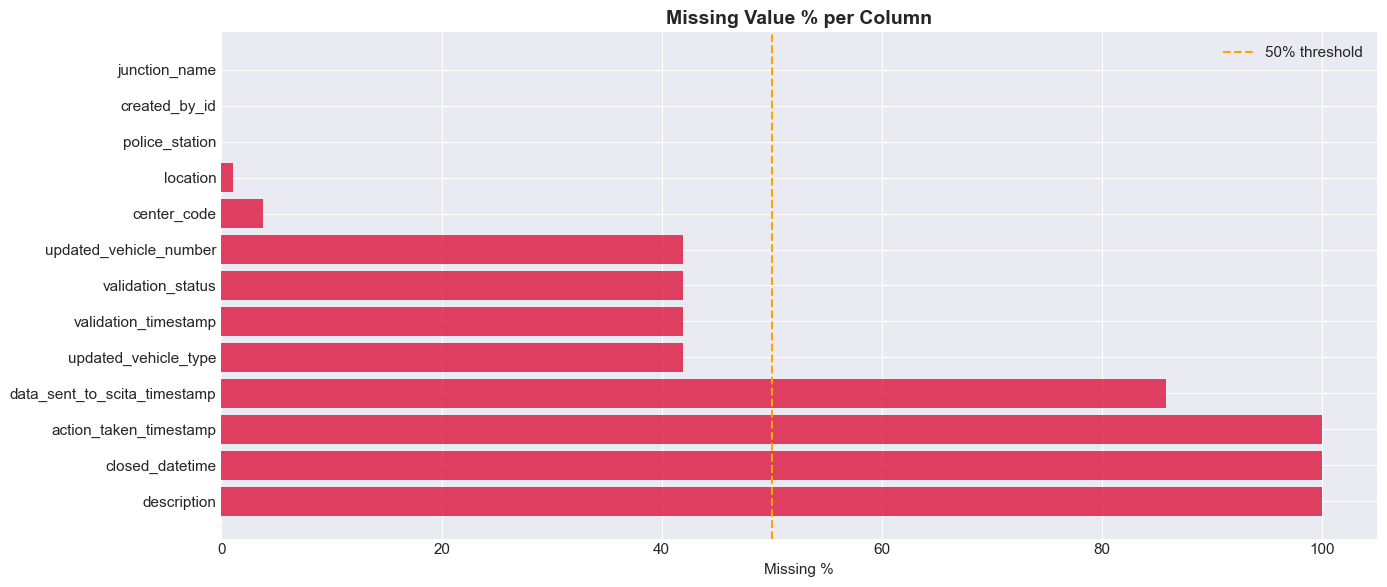

In [6]:
# Visualise missing values
fig, ax = plt.subplots(figsize=(14, 6))
cols_with_missing = missing_report[missing_report['Missing Count'] > 0]
ax.barh(cols_with_missing.index, cols_with_missing['Missing %'], color='crimson', alpha=0.8)
ax.set_xlabel('Missing %')
ax.set_title('Missing Value % per Column', fontsize=14, fontweight='bold')
ax.axvline(50, color='orange', linestyle='--', label='50% threshold')
ax.legend()
plt.tight_layout()
plt.show()

## 3. Understanding `validation_status` — The Key Quality Filter

This column has three values:
- **`approved`** — violation confirmed by a supervisor. HIGH QUALITY. Use for AI models.
- **`rejected`** — violation was disputed/wrong. DO NOT use for hotspot analysis.
- **`NaN/NULL`** — not yet validated. May be real violations but unconfirmed. TREAT WITH CARE.

**Strategy:** For the ML pipeline, we will primarily use `approved` records.
We will separately profile `NULL` records to understand their proportion and characteristics.

In [7]:
val_counts = df['validation_status'].value_counts(dropna=False)
print('validation_status distribution:')
print(val_counts)
print()
print('Percentages:')
print((val_counts / len(df) * 100).round(2))

validation_status distribution:
validation_status
NaN           125254
approved      115400
rejected       49754
created1        7044
processing       678
duplicate        320
Name: count, dtype: int64

Percentages:
validation_status
NaN           41.97
approved      38.67
rejected      16.67
created1       2.36
processing     0.23
duplicate      0.11
Name: count, dtype: float64


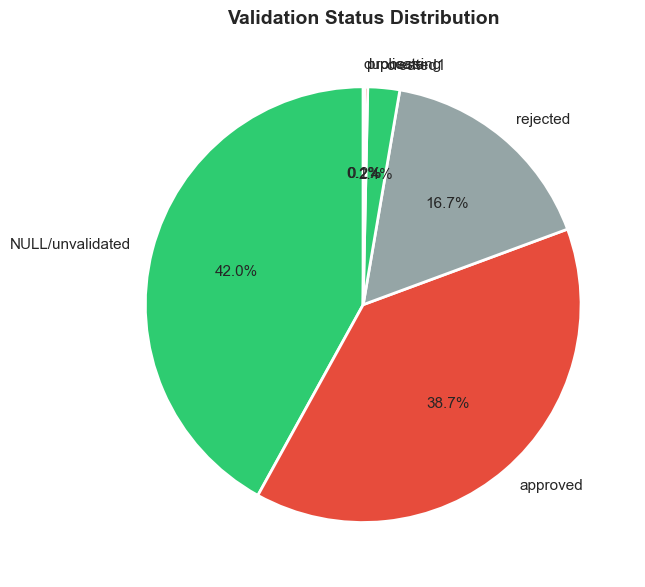

In [8]:
# Pie chart
fig, ax = plt.subplots(figsize=(8, 6))
labels = val_counts.index.fillna('NULL/unvalidated')
colors = ['#2ecc71', '#e74c3c', '#95a5a6']
ax.pie(val_counts.values, labels=labels, autopct='%1.1f%%', colors=colors,
       startangle=90, wedgeprops=dict(edgecolor='white', linewidth=2))
ax.set_title('Validation Status Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [9]:
# Check: do rejected records cluster in specific police stations?
rejected_by_station = (
    df[df['validation_status'] == 'rejected']
    .groupby('police_station')
    .size()
    .sort_values(ascending=False)
    .head(15)
)
print('Top 15 stations with most REJECTED records:')
print(rejected_by_station)

Top 15 stations with most REJECTED records:
police_station
Shivajinagar       5660
Upparpet           4797
HAL Old Airport    3622
Malleshwaram       3080
Vijayanagara       3003
City Market        2963
Rajajinagar        1876
Magadi Road        1704
Kodigehalli        1664
K.R. Pura          1181
Halasuru Gate      1092
HSR Layout         1069
Byatarayanapura    1041
Chikkajala         1009
Mahadevapura        988
dtype: int64


In [10]:
# Check: do NULL validation_status records correlate with data_sent_to_scita=FALSE?
# This would tell us whether unvalidated = not sent to SCITA
cross = pd.crosstab(
    df['data_sent_to_scita'],
    df['validation_status'].fillna('NULL')
)
print('data_sent_to_scita vs validation_status:')
print(cross)

data_sent_to_scita vs validation_status:
validation_status    NULL  approved  created1  duplicate  processing  rejected
data_sent_to_scita                                                            
False               42554         3         0          0           0         0
True                82700    115397      7044        320         678     49754


## 4. Duplicate Detection

From visual inspection, we noticed:
- **FKID000047/48/49** — same `vehicle_number` (FKN00GL0047) at same lat/lng with same timestamp
  → Officer may have submitted same violation multiple times
- **FKID000048/49/50...** — Neeladri Road cluster with many FKN00GL0047/48 repeats
- Same `vehicle_number` + same `created_datetime` + same lat/lng = near-certain duplicate

We must be careful: same vehicle parked at same spot IS legitimate across different dates.

In [11]:
# Check for fully identical rows
full_dups = df.duplicated().sum()
print(f'Fully identical duplicate rows: {full_dups}')

# Check for near-duplicates: same vehicle + same timestamp + same lat/lng
# (same enforcement event submitted multiple times)
near_dup_cols = ['vehicle_number', 'created_datetime', 'latitude', 'longitude']
near_dups = df.duplicated(subset=near_dup_cols, keep=False).sum()
print(f'Near-duplicate rows (same vehicle + timestamp + location): {near_dups}')

# Show examples of near-duplicates
near_dup_examples = df[df.duplicated(subset=near_dup_cols, keep=False)].sort_values('vehicle_number').head(10)
near_dup_examples[['id', 'vehicle_number', 'created_datetime', 'latitude', 'longitude', 'violation_type', 'validation_status']]

Fully identical duplicate rows: 0
Near-duplicate rows (same vehicle + timestamp + location): 8654


,id,vehicle_number,created_datetime,latitude,longitude,violation_type,validation_status
47,FKID000047,FKN00GL0047,2024-03-10 07:10:46+00,12.841853,77.645302,"[""WRONG PARKING""]",NaN
48,FKID000048,FKN00GL0047,2024-03-10 07:10:46+00,12.841853,77.645302,"[""WRONG PARKING""]",NaN
49,FKID000049,FKN00GL0047,2024-03-10 07:10:46+00,12.841853,77.645302,"[""WRONG PARKING""]",NaN
101324,FKID101324,FKN00GL0047,2024-03-10 07:10:46+00,12.841853,77.645302,"[""WRONG PARKING""]",NaN
101323,FKID101323,FKN00GL0047,2024-03-10 07:10:46+00,12.841853,77.645302,"[""WRONG PARKING""]",approved
50,FKID000050,FKN00GL0048,2024-03-10 07:10:46+00,12.841883,77.645345,"[""WRONG PARKING""]",NaN
51,FKID000051,FKN00GL0048,2024-03-10 07:10:46+00,12.841883,77.645345,"[""WRONG PARKING""]",NaN
52,FKID000052,FKN00GL0048,2024-03-10 07:10:46+00,12.841883,77.645345,"[""WRONG PARKING""]",NaN
53,FKID000053,FKN00GL0048,2024-03-10 07:10:46+00,12.841883,77.645345,"[""WRONG PARKING""]",NaN
277732,FKID277732,FKN00GL0048,2024-03-10 07:10:46+00,12.841883,77.645345,"[""WRONG PARKING""]",approved


In [12]:
# Strategy: Keep only one row per (vehicle_number + created_datetime + lat + lng)
# Prefer 'approved' over others when deduplicating
# We'll sort so 'approved' comes first, then drop duplicates keeping first

status_order = {'approved': 0, 'rejected': 1, np.nan: 2}
df['_status_rank'] = df['validation_status'].map(status_order).fillna(2)
df_sorted = df.sort_values('_status_rank')

before = len(df_sorted)
df_deduped = df_sorted.drop_duplicates(subset=near_dup_cols, keep='first').copy()
after = len(df_deduped)

print(f'Before dedup: {before:,}')
print(f'After dedup : {after:,}')
print(f'Removed     : {before - after:,} near-duplicate rows')

df_deduped = df_deduped.drop(columns=['_status_rank'])

Before dedup: 298,450
After dedup : 293,078
Removed     : 5,372 near-duplicate rows


## 5. Parsing Complex Fields

### 5A. `violation_type` — JSON array stored as string
Examples seen:
- `["WRONG PARKING","PARKING NEAR ROAD CROSSING"]`
- `["NO PARKING"]`
- `["NO PARKING","WRONG PARKING","PARKING NEAR BUSTOP/SCHOOL/HOSPITAL ETC","DOUBLE PARKING","PARKING OPPOSITE TO ANOTHER PARKED VEHICLE","PARKING IN A MAIN ROAD"]`

Also spotted `DEFECTIVE NUMBER PLATE` (offence_code 116) — this is a non-parking violation that got included.

### 5B. `offence_code` — JSON array of integers
Known codes from the data:
- 107 → PARKING IN A MAIN ROAD
- 108 → PARKING OPPOSITE TO ANOTHER PARKED VEHICLE  
- 109 → DOUBLE PARKING
- 111 → PARKING NEAR BUSTOP/SCHOOL/HOSPITAL ETC
- 112 → WRONG PARKING
- 113 → NO PARKING
- 116 → DEFECTIVE NUMBER PLATE (non-parking, ignore for congestion analysis)
- 104 → PARKING NEAR ROAD CROSSING

In [13]:
def parse_json_array(value):
    """
    Safely parse the messy JSON-like array strings in violation_type and offence_code.
    Handles: '["WRONG PARKING","NO PARKING"]', '[112,113]', None, NaN
    Returns a Python list or empty list on failure.
    """
    if pd.isna(value) or value == '' or value == 'NULL':
        return []
    try:
        # Replace escaped double-quotes pattern from CSV parsing
        cleaned = str(value).strip()
        result = json.loads(cleaned)
        if isinstance(result, list):
            return result
        return [result]
    except Exception:
        try:
            result = ast.literal_eval(cleaned)
            if isinstance(result, list):
                return result
            return [result]
        except Exception:
            return []

# Apply parsing
df_deduped['violation_list'] = df_deduped['violation_type'].apply(parse_json_array)
df_deduped['offence_code_list'] = df_deduped['offence_code'].apply(parse_json_array)

# Count of violations per record
df_deduped['violation_count'] = df_deduped['violation_list'].apply(len)

# Check parsing success
empty_parse = (df_deduped['violation_count'] == 0).sum()
print(f'Records with 0 parsed violations (parsing failures or truly empty): {empty_parse:,}')
print()
print('violation_count distribution:')
print(df_deduped['violation_count'].value_counts().sort_index())

Records with 0 parsed violations (parsing failures or truly empty): 0

violation_count distribution:
violation_count
1     253728
2      32356
3       5304
4       1161
5        277
6        165
7         51
8         21
9         13
11         1
12         1
Name: count, dtype: int64


In [14]:
# All unique violation types across the entire dataset
all_violations = [v for sublist in df_deduped['violation_list'] for v in sublist]
violation_freq = Counter(all_violations)

print('All violation types and their frequency:')
for vtype, count in violation_freq.most_common():
    print(f'  {vtype:<55} : {count:>8,}')

All violation types and their frequency:
  WRONG PARKING                                           :  161,887
  NO PARKING                                              :  136,627
  PARKING IN A MAIN ROAD                                  :   23,420
  DEFECTIVE NUMBER PLATE                                  :    7,730
  PARKING ON FOOTPATH                                     :    3,665
  PARKING NEAR BUSTOP/SCHOOL/HOSPITAL ETC                 :    2,372
  DOUBLE PARKING                                          :    1,986
  PARKING NEAR ROAD CROSSING                              :    1,632
  REFUSE TO GO FOR HIRE                                   :      884
  PARKING NEAR TRAFFIC LIGHT OR ZEBRA CROSS               :      503
  PARKING OPPOSITE TO ANOTHER PARKED VEHICLE              :      477
  USING BLACK FILM/OTHER MATERIALS                        :      247
  PARKING OTHER THAN BUS STOP                             :      241
  DEMANDING EXCESS FARE                                   :   

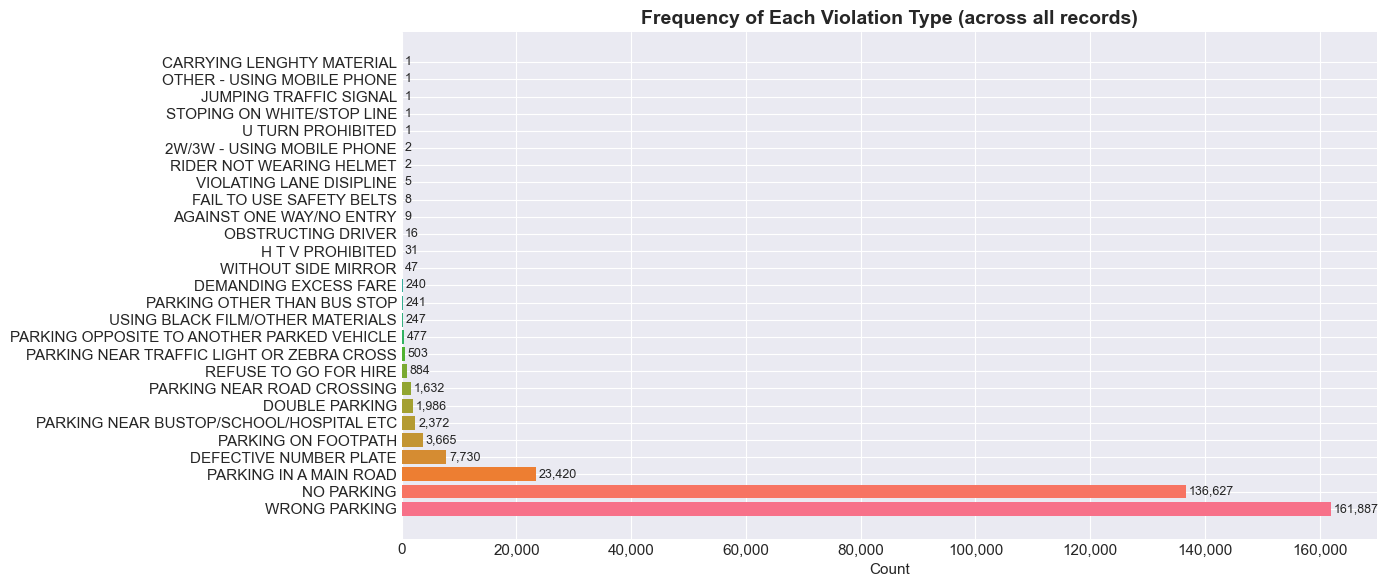

In [15]:
# Visualise violation type frequency
vio_df = pd.DataFrame(violation_freq.most_common(), columns=['violation_type', 'count'])

fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.barh(vio_df['violation_type'], vio_df['count'], color=sns.color_palette('husl', len(vio_df)))
ax.set_xlabel('Count')
ax.set_title('Frequency of Each Violation Type (across all records)', fontsize=14, fontweight='bold')
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
for bar, val in zip(bars, vio_df['count']):
    ax.text(bar.get_width() + 500, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

In [16]:
# Create binary columns for each violation type (one-hot encoded)
VIOLATION_TYPES = [
    'WRONG PARKING',
    'NO PARKING',
    'PARKING IN A MAIN ROAD',
    'DOUBLE PARKING',
    'PARKING OPPOSITE TO ANOTHER PARKED VEHICLE',
    'PARKING NEAR BUSTOP/SCHOOL/HOSPITAL ETC',
    'PARKING NEAR ROAD CROSSING',
    'DEFECTIVE NUMBER PLATE',  # will be excluded from PICI score but kept as column
]

for vtype in VIOLATION_TYPES:
    col_name = 'has_' + vtype.lower().replace(' ', '_').replace('/', '_').replace('.', '')
    df_deduped[col_name] = df_deduped['violation_list'].apply(lambda lst: int(vtype in lst))

print('One-hot violation columns created:')
oh_cols = [c for c in df_deduped.columns if c.startswith('has_')]
print(df_deduped[oh_cols].sum().sort_values(ascending=False))

One-hot violation columns created:
has_wrong_parking                                 161887
has_no_parking                                    136627
has_parking_in_a_main_road                         23420
has_defective_number_plate                          7730
has_parking_near_bustop_school_hospital_etc         2372
has_double_parking                                  1986
has_parking_near_road_crossing                      1632
has_parking_opposite_to_another_parked_vehicle       477
dtype: int64


## 6. Datetime Parsing & Temporal Feature Engineering

In [17]:
# Parse datetime columns — timezone-aware, convert to IST (UTC+5:30)
datetime_cols = ['created_datetime', 'closed_datetime', 'modified_datetime',
                 'validation_timestamp', 'action_taken_timestamp',
                 'data_sent_to_scita_timestamp']

for col in datetime_cols:
    df_deduped[col] = pd.to_datetime(df_deduped[col], utc=True, errors='coerce')
    df_deduped[col] = df_deduped[col].dt.tz_convert('Asia/Kolkata')

# Verify
print('created_datetime sample (IST):')
print(df_deduped['created_datetime'].dropna().head(5))
print()
print(f'Date range: {df_deduped["created_datetime"].min()} → {df_deduped["created_datetime"].max()}')

created_datetime sample (IST):
298431   2024-03-15 03:46:46+05:30
37       2023-11-18 02:58:46+05:30
38       2023-11-18 10:12:46+05:30
39       2023-11-17 09:55:46+05:30
31       2023-11-18 00:12:46+05:30
Name: created_datetime, dtype: datetime64[ns, Asia/Kolkata]

Date range: 2023-11-10 00:41:46+05:30 → 2024-04-08 23:00:46+05:30


In [18]:
# Extract temporal features from created_datetime
dt = df_deduped['created_datetime']

df_deduped['hour']        = df_deduped['created_datetime'].dt.hour.fillna(-1).astype('int64')
df_deduped['day_of_week'] = df_deduped['created_datetime'].dt.dayofweek.fillna(-1).astype('int64')        # 0=Monday, 6=Sunday
df_deduped['day_name']     = dt.dt.day_name()
df_deduped['month']       = df_deduped['created_datetime'].dt.month.fillna(-1).astype('int64')
df_deduped['month_name']   = dt.dt.month_name()
df_deduped['week_of_year'] = df_deduped['created_datetime'].dt.isocalendar().week.fillna(0).astype('int64')
df_deduped['date'] = df_deduped['created_datetime'].dt.date

# Peak hour flag: morning rush 8-11 AM, evening rush 5-9 PM (IST)
df_deduped['is_peak_hour'] = df_deduped['hour'].apply(
    lambda h: 1 if (8 <= h <= 11) or (17 <= h <= 21) else 0
)

# Weekend flag
df_deduped['is_weekend'] = df_deduped['day_of_week'].apply(lambda d: 1 if d >= 5 else 0)

print('Temporal features created:')
print(df_deduped[['hour','day_of_week','day_name','month','month_name','is_peak_hour','is_weekend']].head())

Temporal features created:
        hour  day_of_week  day_name  month month_name  is_peak_hour  \
298431     3            4    Friday      3      March             0   
37         2            5  Saturday     11   November             0   
38        10            5  Saturday     11   November             1   
39         9            4    Friday     11   November             1   
31         0            5  Saturday     11   November             0   

        is_weekend  
298431           0  
37               1  
38               1  
39               0  
31               1  


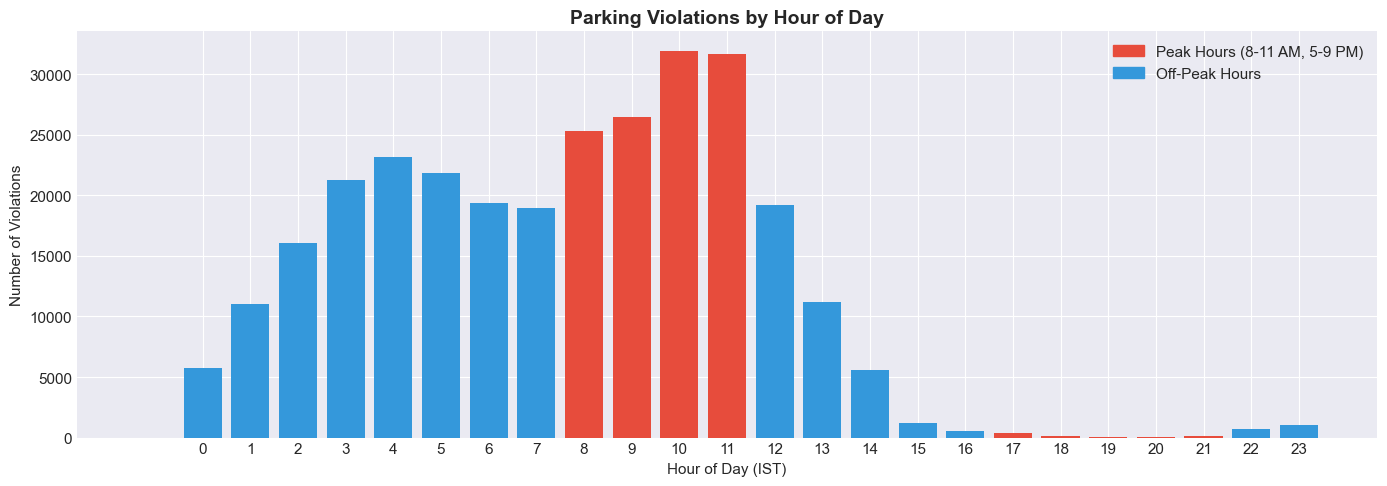

In [19]:
# Violations by hour of day
hourly = df_deduped.groupby('hour').size()

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(hourly.index, hourly.values, color=['#e74c3c' if (8<=h<=11 or 17<=h<=21) else '#3498db' for h in hourly.index])
ax.set_xlabel('Hour of Day (IST)')
ax.set_ylabel('Number of Violations')
ax.set_title('Parking Violations by Hour of Day', fontsize=14, fontweight='bold')
ax.set_xticks(range(0, 24))
ax.legend(handles=[
    plt.Rectangle((0,0),1,1, color='#e74c3c', label='Peak Hours (8-11 AM, 5-9 PM)'),
    plt.Rectangle((0,0),1,1, color='#3498db', label='Off-Peak Hours')
])
plt.tight_layout()
plt.show()

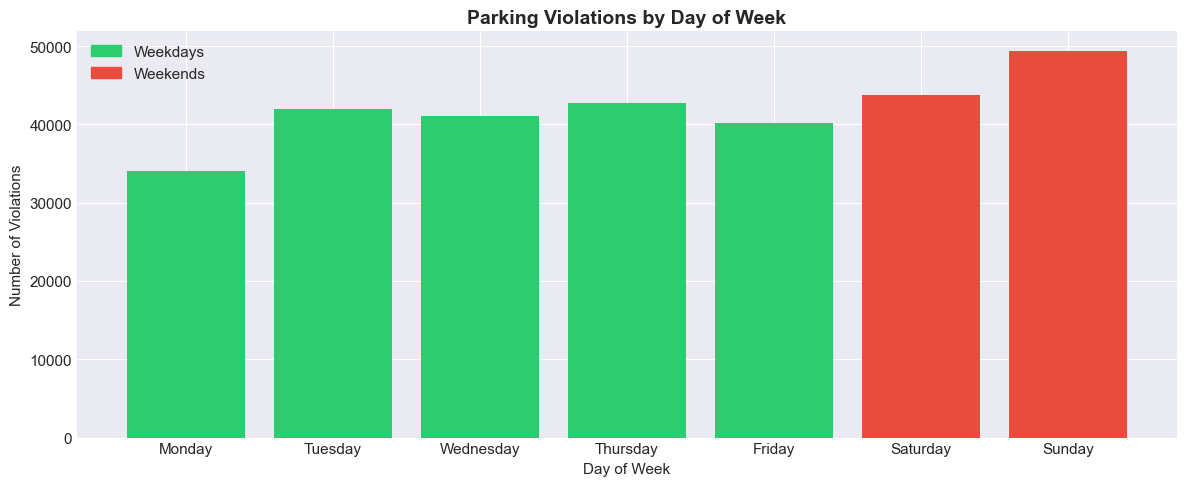

In [20]:
# Violations by day of week
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
daily = df_deduped.groupby('day_name').size().reindex(day_order)

fig, ax = plt.subplots(figsize=(12, 5))
colors = ['#e74c3c' if d in ['Saturday','Sunday'] else '#2ecc71' for d in day_order]
ax.bar(daily.index, daily.values, color=colors)
ax.set_xlabel('Day of Week')
ax.set_ylabel('Number of Violations')
ax.set_title('Parking Violations by Day of Week', fontsize=14, fontweight='bold')
ax.legend(handles=[
    plt.Rectangle((0,0),1,1, color='#2ecc71', label='Weekdays'),
    plt.Rectangle((0,0),1,1, color='#e74c3c', label='Weekends')
])
plt.tight_layout()
plt.show()

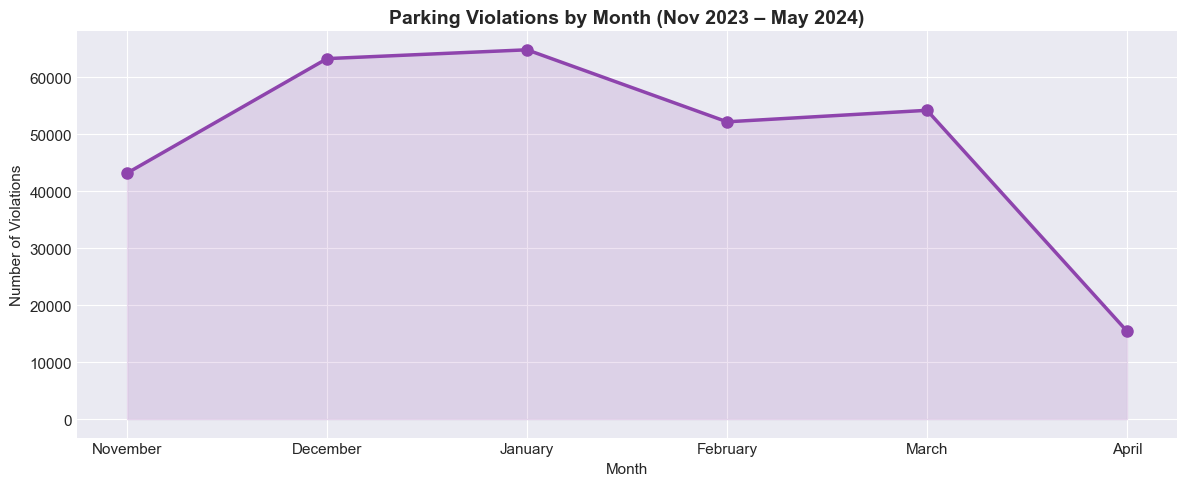

In [21]:
# Violations by month
month_order = ['November','December','January','February','March','April','May']
monthly = df_deduped.groupby('month_name').size()
monthly = monthly.reindex([m for m in month_order if m in monthly.index])

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(monthly.index, monthly.values, marker='o', linewidth=2.5, markersize=8, color='#8e44ad')
ax.fill_between(range(len(monthly)), monthly.values, alpha=0.15, color='#8e44ad')
ax.set_xticks(range(len(monthly)))
ax.set_xticklabels(monthly.index)
ax.set_xlabel('Month')
ax.set_ylabel('Number of Violations')
ax.set_title('Parking Violations by Month (Nov 2023 – May 2024)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Geographic Coverage Analysis

Known Bengaluru bounding box:
- Lat: ~12.75 to ~13.20 (South to North)
- Lng: ~77.45 to ~77.80 (West to East)

Anything outside this is likely a data quality issue or GPS drift.

In [22]:
# Basic stats on coordinates
print('Latitude stats:')
print(df_deduped['latitude'].describe())
print()
print('Longitude stats:')
print(df_deduped['longitude'].describe())

Latitude stats:
count    293078.000000
mean         12.980929
std           0.049469
min          12.802667
25%          12.963429
50%          12.977294
75%          12.997440
max          13.293684
Name: latitude, dtype: float64

Longitude stats:
count    293078.000000
mean         77.600357
std           0.050512
min          77.442553
25%          77.571190
50%          77.584042
75%          77.620285
max          77.771735
Name: longitude, dtype: float64


In [23]:
# Bengaluru bounding box
LAT_MIN, LAT_MAX = 12.75, 13.25
LNG_MIN, LNG_MAX = 77.45, 77.85

# Flag out-of-bounds GPS records
out_of_bounds = df_deduped[
    (df_deduped['latitude'] < LAT_MIN) | (df_deduped['latitude'] > LAT_MAX) |
    (df_deduped['longitude'] < LNG_MIN) | (df_deduped['longitude'] > LNG_MAX) |
    (df_deduped['latitude'].isna()) | (df_deduped['longitude'].isna())
]

print(f'Records with missing or out-of-bounds GPS: {len(out_of_bounds):,}')
if len(out_of_bounds) > 0:
    print('Sample out-of-bounds:')
    print(out_of_bounds[['id','latitude','longitude','location','police_station']].head(10))

Records with missing or out-of-bounds GPS: 46
Sample out-of-bounds:
                id   latitude  longitude  \
1690    FKID001690  13.068613  77.447900   
291720  FKID291720  13.264584  77.718799   
291698  FKID291698  13.266818  77.719236   
165406  FKID165406  13.257144  77.711920   
274304  FKID274304  13.068492  77.449160   
252551  FKID252551  13.257448  77.712265   
139706  FKID139706  13.068991  77.447021   
210436  FKID210436  13.067487  77.449689   
210388  FKID210388  13.067884  77.449157   
209810  FKID209810  13.069766  77.447231   

                                                 location       police_station  
1690    Mumbai Bengaluru Highway, Rajadhani Layout, Ad...    No Police Station  
291720  Bangalore Bellary Road, Nitesh Long Land, Deva...  Devanahalli Airport  
291698  Devanahalli, Devanahalli taluku, Bengaluru Nor...  Devanahalli Airport  
165406  Devanahalli, Devanahalli taluku, Bengaluru Nor...  Devanahalli Airport  
274304  Mumbai Bengaluru Highway, Alur Vil

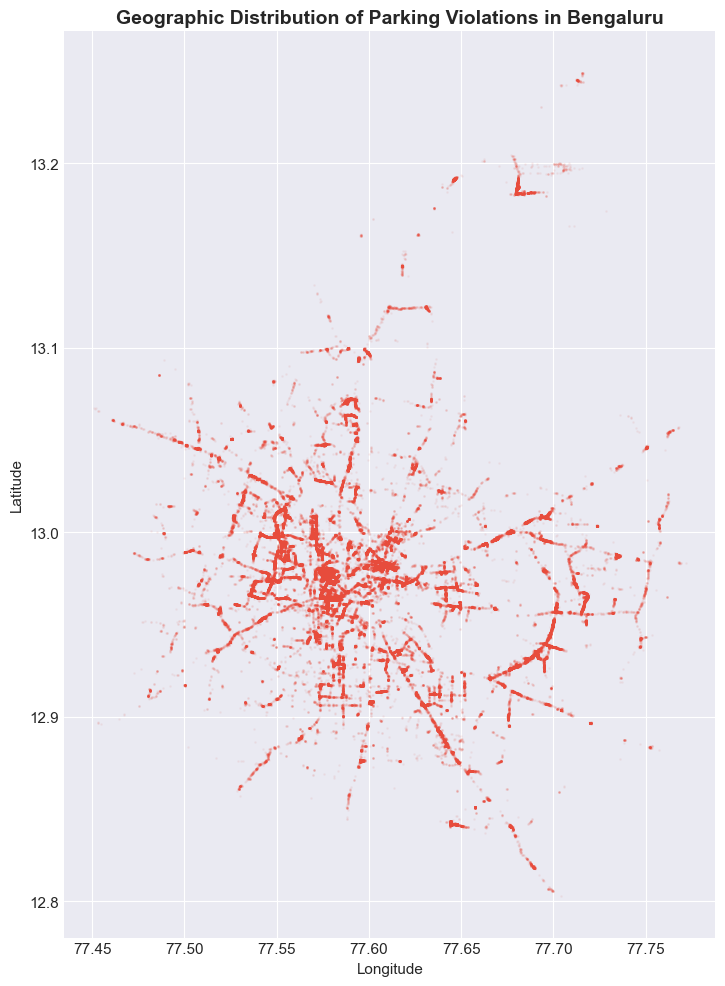

Total records with valid GPS: 293,032


In [24]:
# Scatter plot of all GPS coordinates — gives us the geographic footprint
df_geo = df_deduped.dropna(subset=['latitude','longitude'])
df_geo = df_geo[
    (df_geo['latitude'].between(LAT_MIN, LAT_MAX)) &
    (df_geo['longitude'].between(LNG_MIN, LNG_MAX))
]

fig, ax = plt.subplots(figsize=(10, 10))
ax.scatter(df_geo['longitude'], df_geo['latitude'],
           alpha=0.05, s=1, c='#e74c3c')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Geographic Distribution of Parking Violations in Bengaluru',
             fontsize=14, fontweight='bold')
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

print(f'Total records with valid GPS: {len(df_geo):,}')

## 8. Vehicle Type Analysis

Key observation from raw data: `vehicle_type` (original) vs `updated_vehicle_type` (corrected by validator).
Many records have MAXI-CAB as `updated_vehicle_type` even when `vehicle_type` was CAR.
This is a systematic correction pattern by validators.
We should use `updated_vehicle_type` when available, else fall back to `vehicle_type`.

In [25]:
# How often does updated_vehicle_type differ from vehicle_type?
has_update = df_deduped['updated_vehicle_type'].notna()
differs = (
    df_deduped[has_update]['vehicle_type'] != df_deduped[has_update]['updated_vehicle_type']
).sum()

print(f'Records with updated_vehicle_type: {has_update.sum():,}')
print(f'Of those, vehicle_type was CHANGED during validation: {differs:,}')
print()

# What was it changed FROM and TO most often?
changes = df_deduped[has_update & (
    df_deduped['vehicle_type'] != df_deduped['updated_vehicle_type']
)][['vehicle_type','updated_vehicle_type']]

change_freq = changes.groupby(['vehicle_type','updated_vehicle_type']).size().sort_values(ascending=False).head(15)
print('Most common vehicle type corrections:')
print(change_freq)

Records with updated_vehicle_type: 173,080
Of those, vehicle_type was CHANGED during validation: 6,165

Most common vehicle type corrections:
vehicle_type    updated_vehicle_type
CAR             MAXI-CAB                899
                SCOOTER                 679
SCOOTER         MOTOR CYCLE             645
MOTOR CYCLE     SCOOTER                 466
MAXI-CAB        CAR                     298
CAR             MOTOR CYCLE             290
SCOOTER         CAR                     273
PASSENGER AUTO  SCOOTER                 250
                CAR                     164
MOPED           SCOOTER                 147
SCOOTER         PASSENGER AUTO          140
MOTOR CYCLE     CAR                     112
PASSENGER AUTO  MOTOR CYCLE             105
MAXI-CAB        SCOOTER                 103
CAR             PASSENGER AUTO          103
dtype: int64


In [26]:
# Create final_vehicle_type: use updated when available, else original
df_deduped['final_vehicle_type'] = df_deduped['updated_vehicle_type'].fillna(df_deduped['vehicle_type'])

# Standardise to uppercase and strip whitespace
df_deduped['final_vehicle_type'] = df_deduped['final_vehicle_type'].str.upper().str.strip()

# All unique vehicle types
vtype_counts = df_deduped['final_vehicle_type'].value_counts()
print('All vehicle types (final, after correction):')
print(vtype_counts)

All vehicle types (final, after correction):
final_vehicle_type
SCOOTER                93437
CAR                    86147
MOTOR CYCLE            40361
PASSENGER AUTO         37072
MAXI-CAB               11666
LGV                     8213
GOODS AUTO              2922
MOPED                   2071
PRIVATE BUS             1633
VAN                     1509
TEMPO                   1275
BUS (BMTC/KSRTC)        1238
HGV                     1161
LORRY/GOODS VEHICLE     1105
JEEP                     938
OTHERS                   877
TOURIST BUS              365
SCHOOL VEHICLE           361
TANKER                   253
FACTORY BUS              223
MINI LORRY               190
TRACTOR                   61
Name: count, dtype: int64


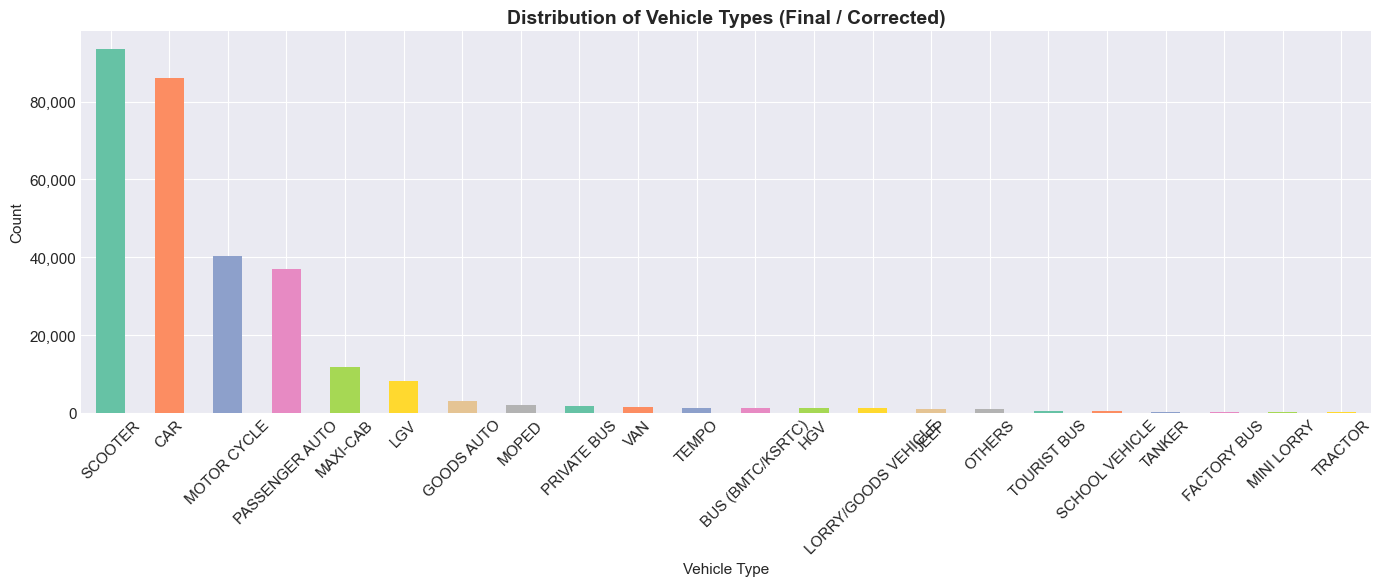

In [27]:
# Visualise vehicle type distribution
fig, ax = plt.subplots(figsize=(14, 6))
vtype_counts.plot(kind='bar', ax=ax, color=sns.color_palette('Set2', len(vtype_counts)))
ax.set_xlabel('Vehicle Type')
ax.set_ylabel('Count')
ax.set_title('Distribution of Vehicle Types (Final / Corrected)', fontsize=14, fontweight='bold')
ax.tick_params(axis='x', rotation=45)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

## 9. Police Station & Junction Analysis

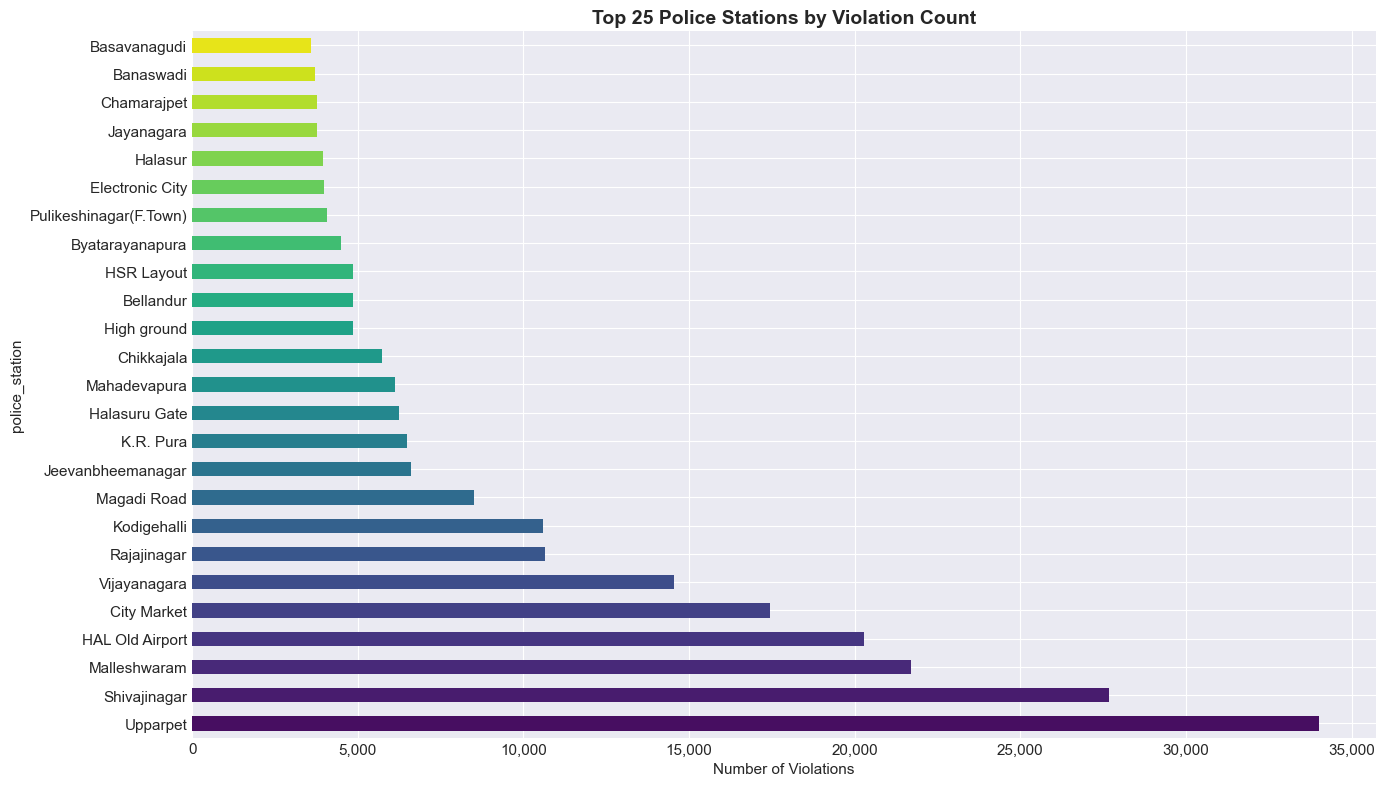

In [28]:
# Top police stations by violation count
station_counts = df_deduped['police_station'].value_counts().head(25)

fig, ax = plt.subplots(figsize=(14, 8))
station_counts.plot(kind='barh', ax=ax, color=sns.color_palette('viridis', 25))
ax.set_xlabel('Number of Violations')
ax.set_title('Top 25 Police Stations by Violation Count', fontsize=14, fontweight='bold')
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

In [29]:
# Junction analysis
# junction_name is either a named junction (e.g., 'BTP044 - Sagar Theatre Junction')
# or 'No Junction' for mid-block violations

df_deduped['has_junction'] = df_deduped['junction_name'].apply(
    lambda x: 0 if (pd.isna(x) or str(x).strip() == 'No Junction') else 1
)

junction_split = df_deduped['has_junction'].value_counts()
print('Junction vs No Junction split:')
print(junction_split)
print(f'\nJunction violations: {junction_split.get(1,0)/len(df_deduped)*100:.1f}%')

# Top named junctions
top_junctions = (
    df_deduped[df_deduped['has_junction'] == 1]
    ['junction_name']
    .value_counts()
    .head(20)
)
print('\nTop 20 most violated junctions:')
print(top_junctions)

Junction vs No Junction split:
has_junction
1    148578
0    144500
Name: count, dtype: int64

Junction violations: 50.7%

Top 20 most violated junctions:
junction_name
BTP051 - Safina Plaza Junction                15214
BTP082 - KR Market Junction                   11388
BTP040 - Elite Junction                       10647
BTP044 - Sagar Theatre Junction               10295
BTP211 - Central Street Junction               5348
BTP058 - Subbanna Junction                     5133
BTP027 - Modi Bridge Junction                  4302
BTP020 - Hosahalli Metro Station               4068
BTP057 - Anand Rao Junction                    3921
BTP080 - NR Road, SP Road Junction             3632
BTP045 - Danvanthri Road Junction              3157
BTP001 - 10th Cross, Dr. Rajkumar Road         2787
BTP083 - AS Char Street, Mysore Road           2745
BTP032 - Windsor Circle                        2717
BTP016 - 5th Main Road, RPC Layout             2473
BTP070 - Cholurpalya Junction, Magadi Road     2260

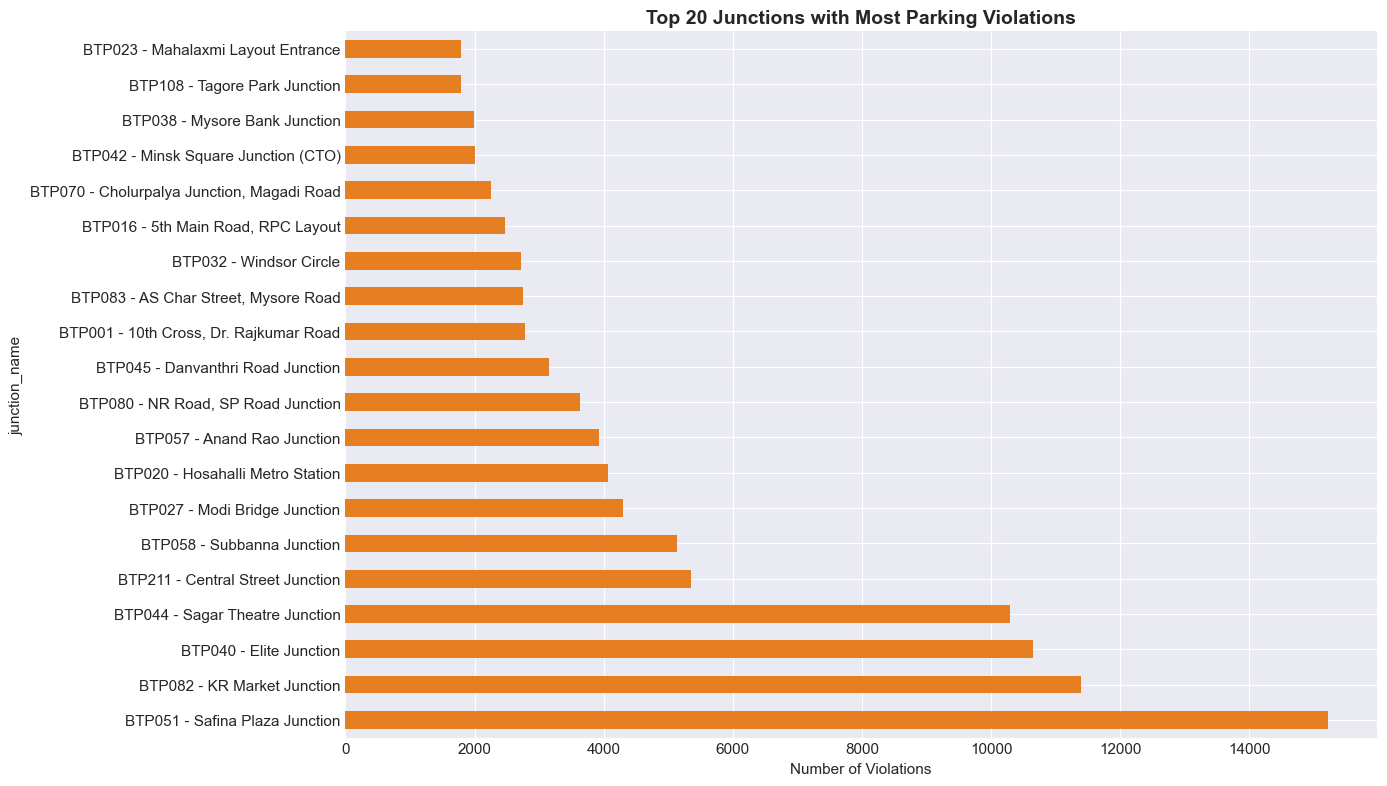

In [30]:
# Visualise top junctions
fig, ax = plt.subplots(figsize=(14, 8))
top_junctions.plot(kind='barh', ax=ax, color='#e67e22')
ax.set_xlabel('Number of Violations')
ax.set_title('Top 20 Junctions with Most Parking Violations', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 10. Enforcement Response Time Analysis

Key insight: The gap between `created_datetime` and `validation_timestamp` tells us how fast BTP validates violations.
The `closed_datetime` being mostly NULL reveals enforcement follow-through is weak.

In [31]:
# closed_datetime NULL analysis
closed_null_pct = df_deduped['closed_datetime'].isna().sum() / len(df_deduped) * 100
print(f'closed_datetime is NULL: {closed_null_pct:.1f}% of records')
print('→ This is a KEY FINDING: enforcement follow-through (case closure) is almost absent.')
print('→ This supports the need for better enforcement prioritisation.')

closed_datetime is NULL: 100.0% of records
→ This is a KEY FINDING: enforcement follow-through (case closure) is almost absent.
→ This supports the need for better enforcement prioritisation.


In [32]:
# Validation response time (hours): created → validated
df_validated = df_deduped[
    df_deduped['validation_timestamp'].notna() &
    df_deduped['created_datetime'].notna()
].copy()

df_validated['validation_lag_hours'] = (
    df_validated['validation_timestamp'] - df_validated['created_datetime']
).dt.total_seconds() / 3600

# Remove negative lags (data entry anomalies)
df_validated = df_validated[df_validated['validation_lag_hours'] >= 0]

print('Validation lag (hours) statistics:')
print(df_validated['validation_lag_hours'].describe().round(2))

# By station — which stations are slowest?
slow_stations = (
    df_validated.groupby('police_station')['validation_lag_hours']
    .median()
    .sort_values(ascending=False)
    .head(15)
)
print('\nTop 15 slowest stations (median validation lag in hours):')
print(slow_stations.round(1))

Validation lag (hours) statistics:
count    172912.00
mean         96.80
std         216.20
min           0.02
25%          19.29
50%          31.04
75%          70.73
max        3664.26
Name: validation_lag_hours, dtype: float64

Top 15 slowest stations (median validation lag in hours):
police_station
Electronic City        47.0
Whitefield             46.0
Devanahalli Airport    45.9
K.S. Layout            45.5
Thalagattapura         45.1
Kamakshipalya          44.6
Hennuru                44.3
Yelahanka              44.3
HAL Old Airport        43.5
Sheshadripuram         43.5
V.V.Puram (C.Pet)      43.5
Adugodi                43.3
Vijayanagara           43.0
Hulimavu               42.8
Madiwala               42.8
Name: validation_lag_hours, dtype: float64


## 11. Repeat Offender Analysis (Preliminary)

In [33]:
# Use final vehicle number (updated_vehicle_number when available)
df_deduped['final_vehicle_number'] = df_deduped['updated_vehicle_number'].fillna(df_deduped['vehicle_number'])

repeat_counts = df_deduped['final_vehicle_number'].value_counts()

print('Vehicle violation frequency distribution:')
print(pd.cut(repeat_counts, bins=[0,1,2,5,10,50,float('inf')],
             labels=['1','2','3-5','6-10','11-50','50+']).value_counts().sort_index())

print(f'\nVehicles with 5+ violations: {(repeat_counts >= 5).sum():,}')
print(f'Vehicles with 10+ violations: {(repeat_counts >= 10).sum():,}')

print('\nTop 20 repeat offenders:')
print(repeat_counts.head(20))

Vehicle violation frequency distribution:
count
1        197814
2         22761
3-5        8712
6-10       1585
11-50       517
50+           1
Name: count, dtype: int64

Vehicles with 5+ violations: 3,138
Vehicles with 10+ violations: 649

Top 20 repeat offenders:
final_vehicle_number
FKN00GL4424     51
FKN00GL17863    41
FKN00GL3514     41
FKN00GL9771     41
FKN00GL2906     35
FKN00GL15265    34
FKN00GL1875     30
FKN00GL14092    29
FKN00GL9852     29
FKN00GL15753    28
FKN00GL1118     28
FKN00GL1175     27
FKN00GL8361     27
FKN00GL8564     26
FKN00GL32387    26
FKN00GL0420     26
FKN00GL24601    26
FKN00GL1498     25
FKN00GL25480    25
FKN00GL7963     25
Name: count, dtype: int64


## 12. `data_sent_to_scita` Analysis

This flag is important — records with `FALSE` were NOT sent to SCITA.
These may represent enforcement gaps (violations captured but not processed).

In [34]:
scita_counts = df_deduped['data_sent_to_scita'].value_counts(dropna=False)
print('data_sent_to_scita distribution:')
print(scita_counts)

# Stations with most FALSE (data NOT sent to SCITA)
false_scita_stations = (
    df_deduped[df_deduped['data_sent_to_scita'] == 'FALSE']
    .groupby('police_station')
    .size()
    .sort_values(ascending=False)
    .head(10)
)
print('\nStations with most violations NOT sent to SCITA:')
print(false_scita_stations)

data_sent_to_scita distribution:
data_sent_to_scita
True     254415
False     38663
Name: count, dtype: int64

Stations with most violations NOT sent to SCITA:
Series([], dtype: int64)


## 13. Final Cleaning Summary & Decisions

Based on the full EDA above, here are our cleaning decisions:

| Issue | Decision |
|---|---|
| Literal 'NULL' strings | → Replace with `np.nan` |
| Near-duplicate records (same vehicle+timestamp+GPS) | → Keep one (prefer `approved`) |
| `validation_status = 'rejected'` | → EXCLUDE from ML pipeline |
| `validation_status = NULL` (unvalidated) | → EXCLUDE for cleanliness; acknowledge as limitation |
| Records with missing lat/lng | → EXCLUDE (can't place on map) |
| Records with GPS outside Bengaluru bbox | → EXCLUDE |
| `violation_type` JSON arrays | → Parse into `violation_list` + one-hot columns |
| `vehicle_type` vs `updated_vehicle_type` | → Use `final_vehicle_type` (prefer updated) |
| `vehicle_number` vs `updated_vehicle_number` | → Use `final_vehicle_number` (prefer updated) |
| `description` (all NULL) | → DROP column |
| `closed_datetime` (mostly NULL) | → Keep as NULL indicator; don't drop |
| `center_code` NULL for some stations | → Fill with -1 (unknown) |
| `DEFECTIVE NUMBER PLATE` violation | → Keep column but EXCLUDE from PICI scoring |

In [35]:
# ============================================================
# FINAL CLEAN DATAFRAME
# ============================================================

df_clean = df_deduped.copy()

# Step 1: Keep only APPROVED records for ML pipeline
df_clean = df_clean[df_clean['validation_status'] == 'approved'].copy()
print(f'After keeping approved only: {len(df_clean):,}')

# Step 2: Drop records with missing GPS
df_clean = df_clean.dropna(subset=['latitude', 'longitude'])
print(f'After dropping missing GPS: {len(df_clean):,}')

# Step 3: Drop records with out-of-bounds GPS
df_clean = df_clean[
    df_clean['latitude'].between(LAT_MIN, LAT_MAX) &
    df_clean['longitude'].between(LNG_MIN, LNG_MAX)
].copy()
print(f'After dropping out-of-bounds GPS: {len(df_clean):,}')

# Step 4: Drop records with 0 parsed violations (parsing failures)
df_clean = df_clean[df_clean['violation_count'] > 0].copy()
print(f'After dropping zero-violation-count records: {len(df_clean):,}')

# Step 5: Drop the description column (all null)
df_clean = df_clean.drop(columns=['description'], errors='ignore')

# Step 6: Fill center_code nulls
df_clean['center_code'] = df_clean['center_code'].fillna(-1).astype(int)

# Step 7: Reset index
df_clean = df_clean.reset_index(drop=True)

print(f'\n✅ Final clean dataset shape: {df_clean.shape}')
print(f'Reduction from raw: {len(df_raw):,} → {len(df_clean):,} ({len(df_clean)/len(df_raw)*100:.1f}% retained)')

After keeping approved only: 115,370
After dropping missing GPS: 115,370
After dropping out-of-bounds GPS: 115,353
After dropping zero-violation-count records: 115,353

✅ Final clean dataset shape: (115353, 46)
Reduction from raw: 298,450 → 115,353 (38.7% retained)


In [36]:
# Final check on clean data
print('Clean dataset info:')
df_clean.info()
print()
print('Remaining nulls in key columns:')
key_cols = ['latitude','longitude','police_station','junction_name',
            'final_vehicle_type','hour','day_of_week','month','violation_count']
print(df_clean[key_cols].isnull().sum())

Clean dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 115353 entries, 0 to 115352
Data columns (total 46 columns):
 #   Column                                          Non-Null Count   Dtype                       
---  ------                                          --------------   -----                       
 0   id                                              115353 non-null  object                      
 1   latitude                                        115353 non-null  float64                     
 2   longitude                                       115353 non-null  float64                     
 3   location                                        114805 non-null  object                      
 4   vehicle_number                                  115353 non-null  object                      
 5   vehicle_type                                    115353 non-null  object                      
 6   violation_type                                  115353 non-null  object 

## 14. Save Clean Data & Sample Upload CSV

In [37]:
# Save the full clean dataset to processed/
CLEAN_PATH = '../data/processed/clean_violations.parquet'
df_clean.to_parquet(CLEAN_PATH, index=False)
print(f'✅ Clean data saved to: {CLEAN_PATH}')
print(f'   File will be much smaller than CSV (parquet compressed)')

# Also save as CSV for compatibility
CSV_CLEAN_PATH = '../data/processed/clean_violations.csv'
df_clean.to_csv(CSV_CLEAN_PATH, index=False)
print(f'✅ Clean CSV saved to: {CSV_CLEAN_PATH}')

✅ Clean data saved to: ../data/processed/clean_violations.parquet
   File will be much smaller than CSV (parquet compressed)
✅ Clean CSV saved to: ../data/processed/clean_violations.csv


In [38]:
# ============================================================
# CREATE SAMPLE UPLOAD CSV
# ============================================================
# This is what judges will use to test the "Upload New Data" feature.
# Must:
#   1. Have the same columns as the raw CSV (so FastAPI pipeline can process it)
#   2. Be clean (all approved, valid GPS, real violations)
#   3. Be diverse (different areas, vehicle types, violation types)
#   4. Be small enough to upload quickly (~200 rows)

# Select columns that match the original raw CSV schema
# (the backend pipeline expects the RAW schema as input, not the enriched clean schema)
raw_schema_cols = [
    'id','latitude','longitude','location','vehicle_number','vehicle_type',
    'violation_type','offence_code','created_datetime','closed_datetime',
    'modified_datetime','device_id','created_by_id','center_code',
    'police_station','data_sent_to_scita','junction_name',
    'action_taken_timestamp','data_sent_to_scita_timestamp',
    'updated_vehicle_number','updated_vehicle_type',
    'validation_status','validation_timestamp'
]

# Stratified sample: pick ~30 rows from each of 6-7 diverse police stations
top_stations = df_clean['police_station'].value_counts().head(7).index.tolist()
sample_parts = []
for station in top_stations:
    station_data = df_clean[df_clean['police_station'] == station]
    n = min(30, len(station_data))
    sample_parts.append(station_data.sample(n=n, random_state=42))

sample_df = pd.concat(sample_parts, ignore_index=True)

# Only keep raw schema columns that exist in df_clean
available_cols = [c for c in raw_schema_cols if c in sample_df.columns]
sample_df = sample_df[available_cols]

SAMPLE_PATH = '../sample_data/sample_upload.csv'
sample_df.to_csv(SAMPLE_PATH, index=False)

print(f'✅ Sample upload CSV saved to: {SAMPLE_PATH}')
print(f'   Rows: {len(sample_df)}')
print(f'   Cols: {len(sample_df.columns)}')
print(f'   Police stations covered: {sample_df["police_station"].nunique()}')
print(f'   Station breakdown:')
print(sample_df['police_station'].value_counts())

✅ Sample upload CSV saved to: ../sample_data/sample_upload.csv
   Rows: 210
   Cols: 23
   Police stations covered: 7
   Station breakdown:
police_station
Upparpet           30
Shivajinagar       30
Malleshwaram       30
HAL Old Airport    30
Vijayanagara       30
City Market        30
Rajajinagar        30
Name: count, dtype: int64


## 15. EDA Summary & Key Findings

Run this cell last to get a printed summary of all key findings discovered in this notebook.

In [39]:
print('=' * 70)
print('  📊 EDA SUMMARY — ParkSense AI | BTP Parking Violations')
print('=' * 70)

print(f"""
📁 DATASET
   Total raw records          : {len(df_raw):>10,}
   After deduplication        : {len(df_deduped):>10,}
   Final CLEAN (approved+GPS) : {len(df_clean):>10,}
   Columns (original)         : {df_raw.shape[1]:>10}

📅 TIME RANGE
   From  : {df_clean['created_datetime'].min()}
   To    : {df_clean['created_datetime'].max()}

✅ VALIDATION STATUS (raw)
   approved    : {(df_raw['validation_status']=='approved').sum():>10,}
   rejected    : {(df_raw['validation_status']=='rejected').sum():>10,}
   unvalidated : {df_raw['validation_status'].isna().sum():>10,}

🚗 VEHICLE TYPES (clean data)
{df_clean['final_vehicle_type'].value_counts().head(6).to_string()}

🚫 TOP VIOLATION TYPES (clean data)
{pd.Series(Counter([v for lst in df_clean['violation_list'] for v in lst])).sort_values(ascending=False).head(7).to_string()}

🗺️  GEOGRAPHY
   Police stations covered    : {df_clean['police_station'].nunique():>10}
   Named junctions            : {df_clean[df_clean['has_junction']==1]['junction_name'].nunique():>10}
   Violation % at junctions   : {df_clean['has_junction'].mean()*100:>9.1f}%

⏰ TEMPORAL
   Peak hour violations %     : {df_clean['is_peak_hour'].mean()*100:>9.1f}%
   Weekend violations %       : {df_clean['is_weekend'].mean()*100:>9.1f}%

🔁 REPEAT OFFENDERS
   Unique vehicles            : {df_clean['final_vehicle_number'].nunique():>10,}
   Vehicles with 5+ violations: {(df_clean['final_vehicle_number'].value_counts()>=5).sum():>10,}

📭 ENFORCEMENT GAPS
   closed_datetime NULL %     : {df_clean['closed_datetime'].isna().mean()*100:>9.1f}%
   data_sent_to_scita=FALSE % : {(df_raw['data_sent_to_scita']=='FALSE').mean()*100:>9.1f}%
""")

print('=' * 70)
print('  ✅ Ready to proceed to Notebook 02: Feature Engineering')
print('=' * 70)

  📊 EDA SUMMARY — ParkSense AI | BTP Parking Violations

📁 DATASET
   Total raw records          :    298,450
   After deduplication        :    293,078
   Final CLEAN (approved+GPS) :    115,353
   Columns (original)         :         24

📅 TIME RANGE
   From  : 2023-11-10 00:41:46+05:30
   To    : 2024-03-29 08:38:46+05:30

✅ VALIDATION STATUS (raw)
   approved    :    115,400
   rejected    :     49,754
   unvalidated :    125,254

🚗 VEHICLE TYPES (clean data)
final_vehicle_type
SCOOTER           36292
CAR               35592
MOTOR CYCLE       15540
PASSENGER AUTO    13614
MAXI-CAB           5344
LGV                3186

🚫 TOP VIOLATION TYPES (clean data)
WRONG PARKING                              60151
NO PARKING                                 57191
PARKING IN A MAIN ROAD                      8567
DEFECTIVE NUMBER PLATE                      3061
PARKING ON FOOTPATH                         1303
PARKING NEAR BUSTOP/SCHOOL/HOSPITAL ETC      867
DOUBLE PARKING                         